In [8]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


# NSL-KDD Dataset: Comprehensive Guide

## Dataset Overview

### What is the NSL-KDD Dataset?
full form is Network State Long-Run Knowledge Discovery Dataset (often referred to in literature simply as the NSL-KDD dataset or Network Security Laboratory Knowledge Discovery dataset).
NSL-KDD is a benchmark dataset for network intrusion detection. It's an improved version of the original KDD Cup 1999 dataset, which was created by MIT Lincoln Labs for the DARPA Intrusion Detection Evaluation Program.

### Why NSL-KDD?
- **Standard Benchmark**: Most widely used dataset for IDS research
- **Labeled Data**: Every connection is tagged as normal or specific attack type
- **Realistic**: Simulates real network traffic with various attack scenarios
- **Manageable Size**: Perfect for learning and prototyping
- **Comparable Results**: Allows benchmarking against other studies

### Where is it Used?
- **Academic Research**: 1000+ papers use this dataset
- **Industry**: Baseline testing for commercial IDS products
- **Competitions**: Used in Kaggle competitions
- **Education**: Most universities use it to teach network security

### How it Relates to Our Project
We're building an AI-powered Intrusion Detection System. The NSL-KDD dataset provides the ground truth data needed to:
1. Train our model to recognize attack patterns
2. Test our model's accuracy
3. Compare our performance with industry standards
4. Understand what network features indicate attacks

### What Does the Data Represent?
Each row represents a single network connection (or session). The features describe various aspects of that connection, and the label tells us if it was normal or an attack.

---

## Column Explanations

**Total**: 41 Features + 1 Label + 1 Difficulty Score

### Basic Features (Individual TCP Connections)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 1 | **duration** | Length of connection (seconds) | High duration might indicate suspicious activity |
| 2 | **protocol_type** | Network protocol used (tcp, udp, icmp) | Different protocols have different attack patterns |
| 3 | **service** | Network service on destination (http, ftp, smtp, ssh) | Certain services are more vulnerable to attacks |
| 4 | **flag** | Status of the connection (SF, S0, REJ) | Indicates connection state and success/failure |
| 5 | **src_bytes** | Data bytes from source to destination | Very high values might indicate data exfiltration |
| 6 | **dst_bytes** | Data bytes from destination to source | Asymmetric bytes often indicate different behavior |
| 7 | **land** | If source and destination IPs are same (1) or different (0) | Land attack detection (should be rare) |

### Content Features (Inside the Connection)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 8 | **wrong_fragment** | Number of wrong fragments | Fragmentation attacks often increase this |
| 9 | **urgent** | Number of urgent packets | Unusually high urgent packets may indicate attacks |
| 10 | **hot** | Number of "hot" indicators | System-level suspicious activities |
| 11 | **num_failed_logins** | Failed login attempts | High values = brute force attempts |
| 12 | **logged_in** | Successfully logged in (1) or not (0) | Normal behavior vs unauthorized access |
| 13 | **num_compromised** | Number of compromised conditions | System compromise indicators |
| 14 | **root_shell** | Root shell obtained (1) or not (0) | Critical privilege escalation indicator |
| 15 | **su_attempted** | "su" command attempted (1) or not (0) | Attempts to gain root access |
| 16 | **num_root** | Number of root accesses | Unauthorized root access attempts |
| 17 | **num_file_creations** | Number of file creation operations | Malware often creates files |
| 18 | **num_shells** | Number of shell prompts | Remote shell access attempts |
| 19 | **num_access_files** | Number of access to files | File access patterns |
| 20 | **num_outbound_cmds** | Number of outbound commands | Rare in normal traffic, indicates compromise |
| 21 | **is_host_login** | If login is on host (1) or not (0) | User authentication patterns |
| 22 | **is_guest_login** | Guest login (1) or not (0) | Guest accounts are often exploited |

### Time-Based Traffic Features (2-second Window)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 23 | **count** | Number of connections to same host in past 2 seconds | Rapid connections = scanning/attack |
| 24 | **srv_count** | Number of connections to same service in past 2 seconds | Service-specific attacks |
| 25 | **serror_rate** | % of connections with SYN errors | Connection attempts failures |
| 26 | **srv_serror_rate** | % of connections to same service with SYN errors | Service-specific issues |
| 27 | **rerror_rate** | % of connections with REJ errors | Rejected connections |
| 28 | **srv_rerror_rate** | % of connections to same service with REJ errors | Service-specific rejections |
| 29 | **same_srv_rate** | % of connections to same service | Consistent service usage patterns |
| 30 | **diff_srv_rate** | % of connections to different services | Unusual service variety = scanning |
| 31 | **srv_diff_host_rate** | % of connections to different hosts | Unusual host variety = scanning |

### Host-Based Traffic Features (100-connection Window)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 32 | **dst_host_count** | Count of connections to same destination host | Host targeting patterns |
| 33 | **dst_host_srv_count** | Count of connections to same service on destination host | Service targeting |
| 34 | **dst_host_same_srv_rate** | % of connections to same service on destination host | Service consistency |
| 35 | **dst_host_diff_srv_rate** | % of connections to different services on destination host | Service diversity = scanning |
| 36 | **dst_host_same_src_port_rate** | % of connections from same source port | Source port consistency |
| 37 | **dst_host_srv_diff_host_rate** | % of connections to different hosts with same service | Service-based targeting |
| 38 | **dst_host_serror_rate** | % of connections with SYN errors to destination | Failed connections |
| 39 | **dst_host_srv_serror_rate** | % of connections to same service with SYN errors | Service-specific failures |
| 40 | **dst_host_rerror_rate** | % of connections with REJ errors to destination | Rejected connections |
| 41 | **dst_host_srv_rerror_rate** | % of connections to same service with REJ errors | Service-specific rejections |

### Label (Target Variable)

| # | Feature | Description |
|---|---------|-------------|
| 42 | **label** | Type of connection: 'normal' or attack type |
| 43 | **difficulty** | Complexity score of detection (not used in our project) |

---

## Attack Types Explained

### 1. DoS (Denial of Service)
- **Examples**: back, land, neptune, pod, smurf, teardrop
- **Goal**: Make service unavailable to legitimate users
- **Pattern**: High volume, many connections

### 2. Probing
- **Examples**: ipsweep, nmap, portsweep, satan
- **Goal**: Gather information about network
- **Pattern**: Unusual port/service combinations

### 3. R2L (Remote to Local)
- **Examples**: ftp_write, guess_passwd, imap, multihop, spy, warezclient, warezmaster
- **Goal**: Gain unauthorized access to local system
- **Pattern**: Authentication attempts, file operations

### 4. U2R (User to Root)
- **Examples**: buffer_overflow, loadmodule, perl, rootkit
- **Goal**: Gain root/administrator privileges
- **Pattern**: Privilege escalation attempts

---

## Why These Features Matter for Our AI Model

1. **Network Behavior**: Features capture normal vs malicious patterns
2. **Temporal Patterns**: Time-based features detect scanning/attacks
3. **Statistical Patterns**: Rate-based features identify anomalies
4. **Protocol Knowledge**: Features reflect network protocol characteristics
5. **Behavioral Signatures**: Different attacks leave different footprints

In [11]:
# Cell 2: Load the CSV files
# Since you converted to CSV, loading should be straightforward

# Define column names (NSL-KDD has 42 features + 1 label + 1 difficulty)
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Load the data
train_df = pd.read_csv('/home/vboxuser/WORK/AI AND ML/PyCharmMiscProject/Projects/ai_network_ids/data/test.csv', header=None, names=columns)
test_df = pd.read_csv('/home/vboxuser/WORK/AI AND ML/PyCharmMiscProject/Projects/ai_network_ids/data/test.csv', header=None, names=columns)

print(f"✅ Training data loaded: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"✅ Test data loaded: {test_df.shape[0]:,} rows, {test_df.shape[1]} columns")

# Combine for full analysis
df = pd.concat([train_df, test_df], ignore_index=True)
print(f"✅ Combined dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Display first few rows
df.head()

✅ Training data loaded: 22,544 rows, 43 columns
✅ Test data loaded: 22,544 rows, 43 columns
✅ Combined dataset: 45,088 rows, 43 columns


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.0,0.00,1.0,1.0,0.04,0.06,0.00,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136,1,0.0,0.00,1.0,1.0,0.01,0.06,0.00,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.00,0.0,0.0,1.00,0.00,0.00,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,65,0.0,0.00,0.0,0.0,1.00,0.00,1.00,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.0,0.12,1.0,0.5,1.00,0.00,0.75,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [12]:
# Cell 3: Dataset Overview

print("="*80)
print("DATASET OVERVIEW")
print("="*80)

# Basic info
print("\n📊 Data Types:")
print(df.dtypes.value_counts())

print("\n📊 Memory Usage:")
print(f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📊 Missing Values:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing_values[missing_values > 0])

print("\n📊 Statistical Summary (Numerical Features):")
df.describe().T

print("\n📊 Statistical Summary (Categorical Features):")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

DATASET OVERVIEW

📊 Data Types:
int64      24
float64    15
object      4
Name: count, dtype: int64

📊 Memory Usage:
23.98 MB

📊 Missing Values:
✅ No missing values found!

📊 Statistical Summary (Numerical Features):

📊 Statistical Summary (Categorical Features):

protocol_type:
protocol_type
tcp     37760
udp      5242
icmp     2086
Name: count, dtype: int64

service:
service
http       15706
private     9548
telnet      3252
pop_3       2038
smtp        1868
Name: count, dtype: int64

flag:
flag
SF      29750
REJ      7700
S0       4026
RSTO     1546
RSTR     1338
Name: count, dtype: int64

label:
label
normal          19422
neptune          9314
guess_passwd     2462
mscan            1992
warezmaster      1888
Name: count, dtype: int64


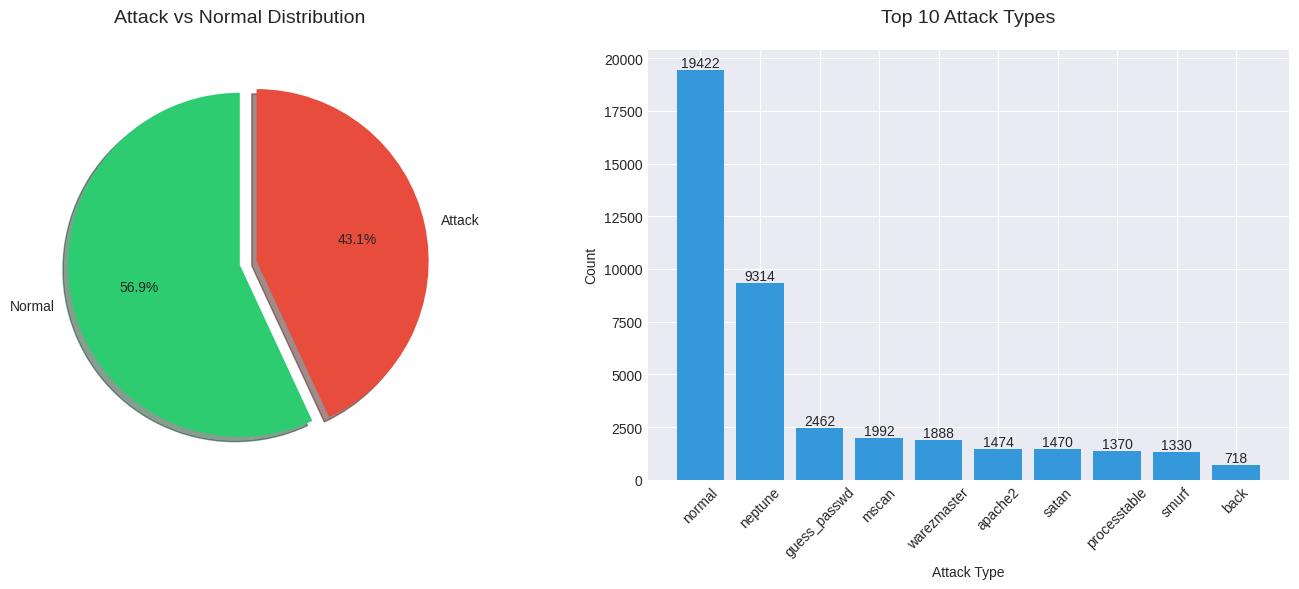

CLASS DISTRIBUTION STATISTICS
Total samples: 45,088
Normal samples: 19,422 (43.08%)
Attack samples: 25,666 (56.92%)

⚠️  Imbalance Ratio: 0.76:1


In [19]:
# Cell 4: Target Variable Analysis (Matplotlib/Seaborn Version)

import matplotlib.pyplot as plt
import seaborn as sns

# Create binary target (Normal vs Attack)
df['attack'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Pie chart for binary classification
attack_counts = df['attack'].value_counts()
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
axes[0].pie(attack_counts.values, 
            labels=['Normal', 'Attack'],
            autopct='%1.1f%%',
            colors=colors,
            explode=explode,
            shadow=True,
            startangle=90)
axes[0].set_title('Attack vs Normal Distribution', fontsize=14, pad=20)

# 2. Bar chart for attack types
attack_types = df['label'].value_counts().head(10)
bars = axes[1].bar(attack_types.index, attack_types.values, color='#3498db')
axes[1].set_title('Top 10 Attack Types', fontsize=14, pad=20)
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print("CLASS DISTRIBUTION STATISTICS")
print("="*80)
total = len(df)
print(f"Total samples: {total:,}")
print(f"Normal samples: {sum(df['attack'] == 0):,} ({sum(df['attack'] == 0)/total*100:.2f}%)")
print(f"Attack samples: {sum(df['attack'] == 1):,} ({sum(df['attack'] == 1)/total*100:.2f}%)")
print(f"\n⚠️  Imbalance Ratio: {sum(df['attack'] == 0)/sum(df['attack'] == 1):.2f}:1")

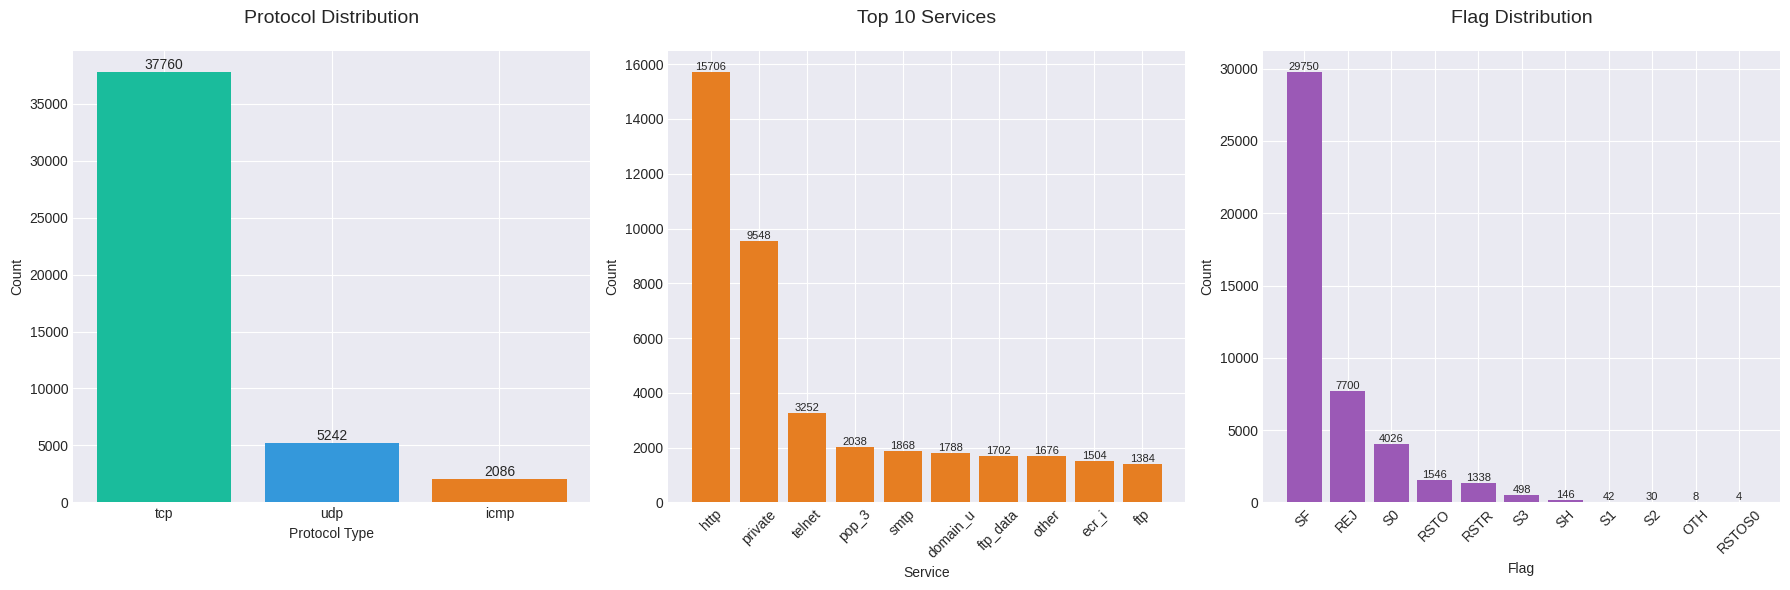

PROTOCOL & SERVICE INSIGHTS

Dominant Protocol: tcp (83.7%)
Most Common Service: http (34.8%)
Most Common Flag: SF (66.0%)


In [21]:
# Cell 5: Protocol and Service Analysis (Matplotlib Version)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Protocol distribution
protocol_counts = df['protocol_type'].value_counts()
bars1 = axes[0].bar(protocol_counts.index, protocol_counts.values, 
                    color=['#1abc9c', '#3498db', '#e67e22'])
axes[0].set_title('Protocol Distribution', fontsize=14, pad=20)
axes[0].set_xlabel('Protocol Type')
axes[0].set_ylabel('Count')

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

# 2. Service distribution (top 10)
service_counts = df['service'].value_counts().head(10)
bars2 = axes[1].bar(service_counts.index, service_counts.values, color='#e67e22')
axes[1].set_title('Top 10 Services', fontsize=14, pad=20)
axes[1].set_xlabel('Service')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)

# 3. Flag distribution
flag_counts = df['flag'].value_counts()
bars3 = axes[2].bar(flag_counts.index, flag_counts.values, color='#9b59b6')
axes[2].set_title('Flag Distribution', fontsize=14, pad=20)
axes[2].set_xlabel('Flag')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print insights
print("="*80)
print("PROTOCOL & SERVICE INSIGHTS")
print("="*80)
print(f"\nDominant Protocol: {protocol_counts.index[0]} ({protocol_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"Most Common Service: {service_counts.index[0]} ({service_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"Most Common Flag: {flag_counts.index[0]} ({flag_counts.iloc[0]/len(df)*100:.1f}%)")

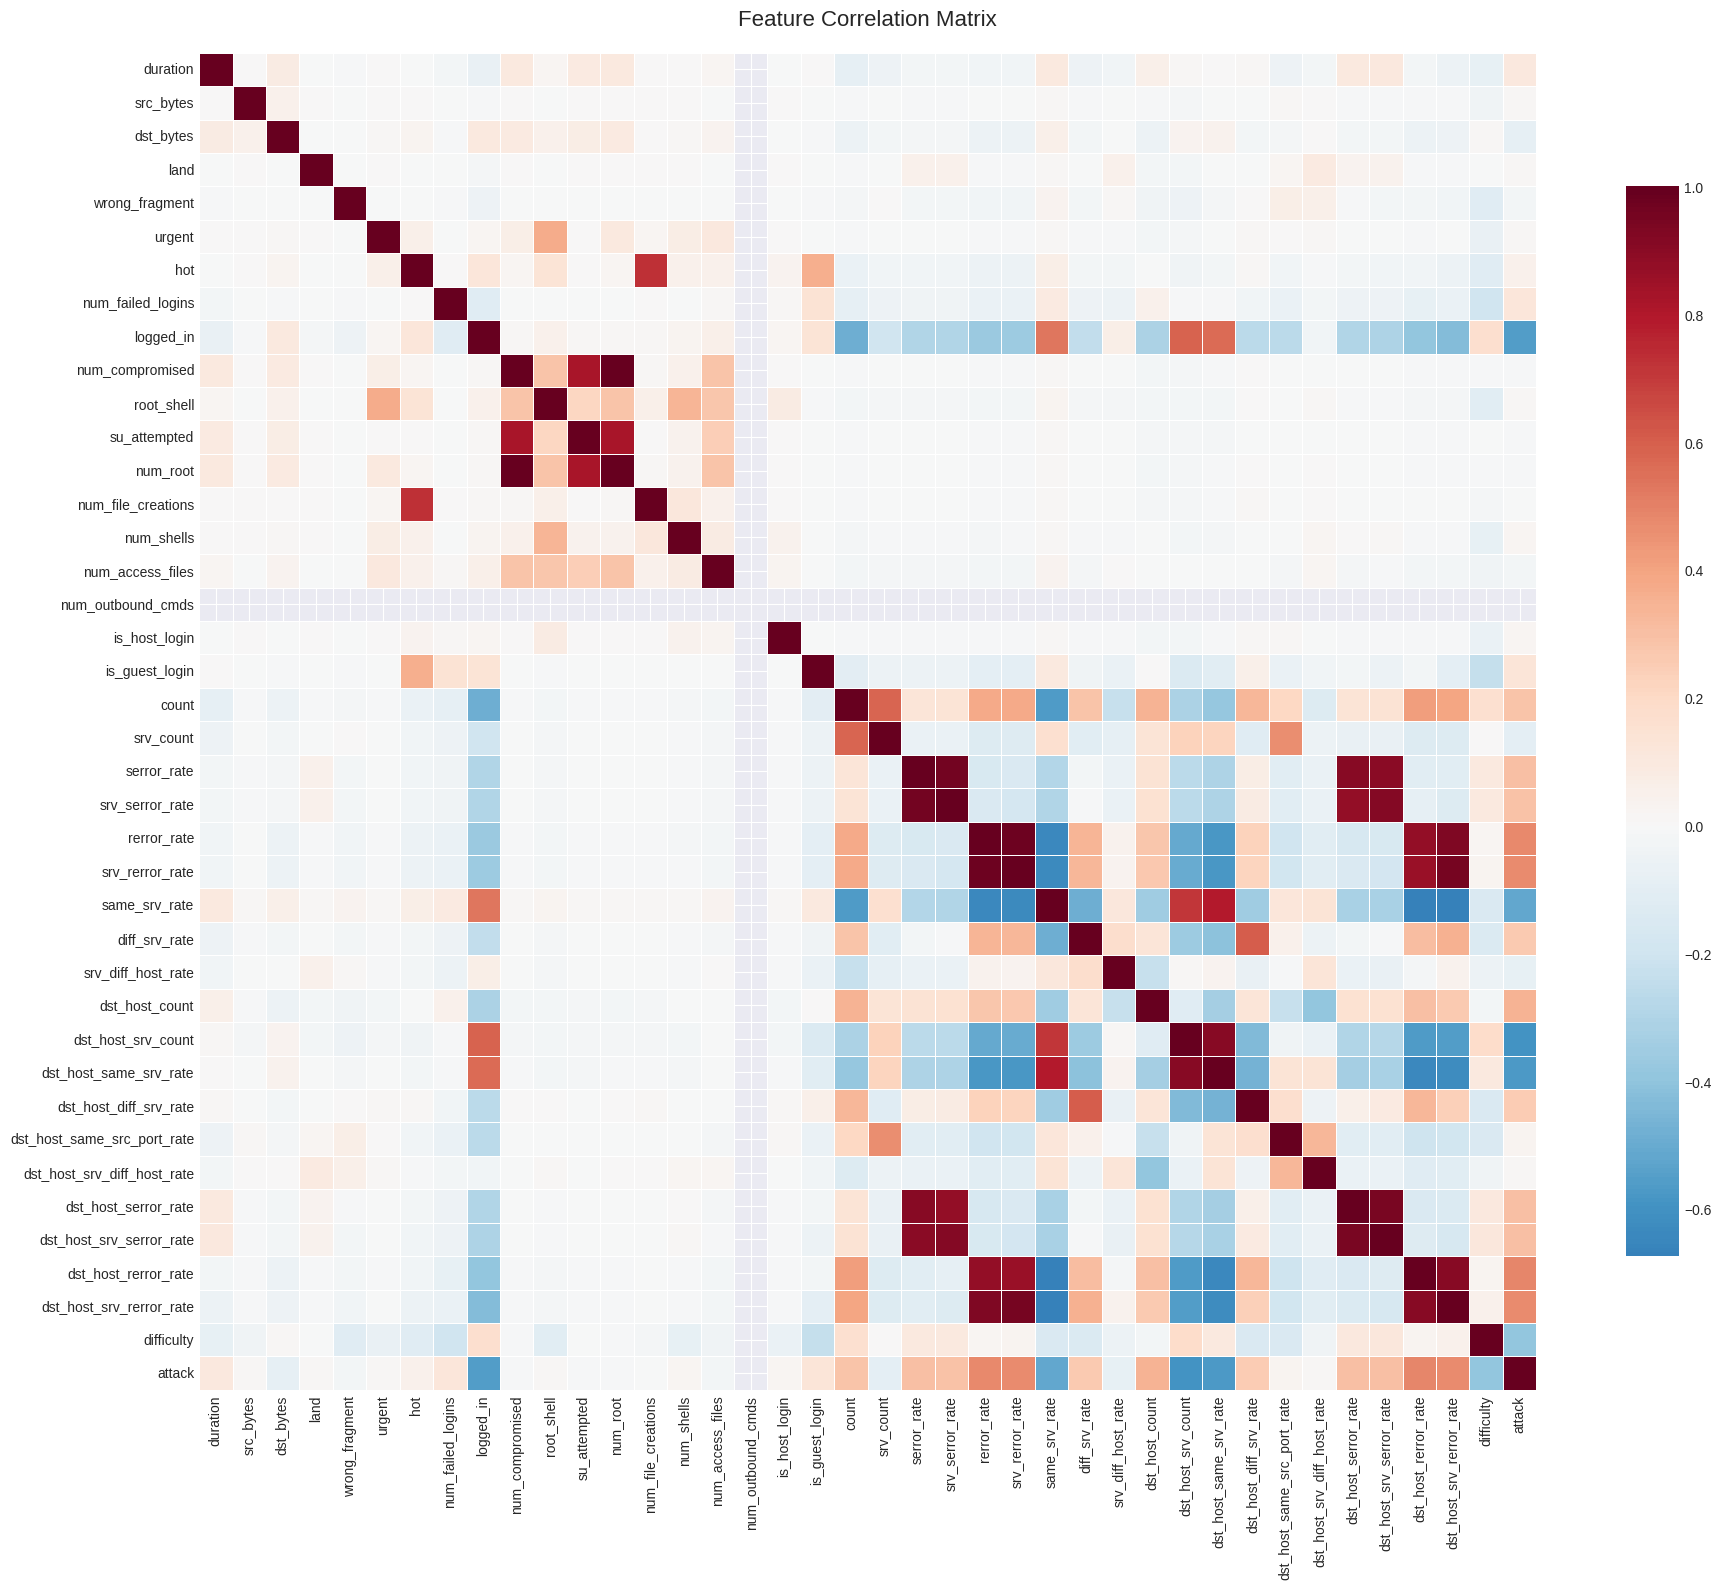

TOP 10 FEATURES CORRELATED WITH ATTACK
dst_host_rerror_rate: 0.4882
rerror_rate         : 0.4811
srv_rerror_rate     : 0.4745
dst_host_srv_rerror_rate: 0.4726
dst_host_count      : 0.3518
dst_host_srv_serror_rate: 0.3003
dst_host_serror_rate: 0.2988
serror_rate         : 0.2938
srv_serror_rate     : 0.2931
count               : 0.2812


In [18]:
# Cell 6: Correlation Analysis

# Select only numerical features for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Plot correlation matrix with attacks
plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    cmap='RdBu_r',
    center=0,
    annot=False,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Top correlated features with attack
print("="*80)
print("TOP 10 FEATURES CORRELATED WITH ATTACK")
print("="*80)
attack_corr = correlation_matrix['attack'].sort_values(ascending=False)
for feature, corr in attack_corr[1:11].items():
    print(f"{feature:20s}: {corr:.4f}")